# 数据准备

#### 数据连接

In [1]:
'''在设定参数位置设定参数。可以求解每年的最优种植方案'''
import pandas as pd
import numpy as np
land=pd.read_excel("../data/附件1.xlsx",0)
crop = pd.read_excel("../data/附件1.xlsx", 1)
crop_2023 = pd.read_excel("../data/附件2.xlsx", 0)
cropStatistics_2023 = pd.read_excel("../data/附件2.xlsx", 1)

In [2]:
cropStatistics=pd.merge(cropStatistics_2023,crop[['作物编号','作物类型']],on='作物编号',how='left').drop(columns=['序号'])
#把智慧大棚第一季的种植情况加入
smart_greenhouse=cropStatistics[(cropStatistics['地块类型']=='普通大棚 ') & (cropStatistics['种植季次']=='第一季')]
dict={'普通大棚 ':'智慧大棚'}
smart_greenhouse=smart_greenhouse.replace({'地块类型':dict})
cropStatistics=pd.concat([cropStatistics,smart_greenhouse],axis=0).reset_index(drop=True)
#cropStatistics.to_csv('../data/cropStatistics.csv',index=False)

In [3]:
crop_2023=crop_2023.fillna(method='ffill')#.drop(columns=['地块名称'])
land.rename(columns={'地块名称':'种植地块'},inplace=True)
crop_2023=pd.merge(crop_2023,land,on=['种植地块'],how='left')
crop_2023 = crop_2023.groupby(['作物编号', '种植季次','地块类型'])['种植面积/亩'].sum().reset_index()

In [4]:

cropStatistics = pd.merge(cropStatistics, crop_2023[['作物编号', '地块类型', '种植面积/亩']], on=[
                          '作物编号', '地块类型'], how='left')
#cropStatistics.to_csv('../data/cropStatistics.csv', index=False)

cropStatistics = cropStatistics.fillna(0)

#### 标签编码

#### 导入data_use

In [5]:
years=range(2024,2030+1)
seasons=range(0,1+1)
plots=range(0,53+1)
crops=range(1,41+1)
# 创建行索引
index = pd.MultiIndex.from_product([years, seasons, plots, crops], names=['year', 'season', 'plot', 'crop'])
#创建 DataFrame 并初始化所有值为0
df = pd.DataFrame(index=index, columns=['value','是否种作物','地块类型'], data=0).reset_index()



In [6]:
crop_data=pd.read_csv('../data/data_use.csv')
#crop_data['种植季次']=le2.transform(crop_data['种植季次'])
#crop_data['地块名称']=le3.transform(crop_data['地块名称'])
#crop_data['地块类型']=le4.transform(crop_data['地块类型'])
crop_data.head()


,作物编号,作物名称,地块类型,种植季次,亩产量/斤,销售单价平均值/(元/斤),种植成本/(元/亩),预期销售量/斤,地块名称,地块面积/亩,豆类
0,1,黄豆,平旱地,第一季,400.0,3.25,400.0,57000.0,A1,80.0,1
1,1,黄豆,平旱地,第一季,400.0,3.25,400.0,57000.0,A2,55.0,1
2,1,黄豆,平旱地,第一季,400.0,3.25,400.0,57000.0,A3,35.0,1
3,1,黄豆,平旱地,第一季,400.0,3.25,400.0,57000.0,A4,72.0,1
4,1,黄豆,平旱地,第一季,400.0,3.25,400.0,57000.0,A5,68.0,1


In [7]:
crop_data['种植规模']=0
crop_data['是否种']=0
crop_data.head()
usage=crop_data

# 参数设定

In [8]:
'''参数设定'''
##########################################################################
import warnings
warnings.filterwarnings("ignore")

#滞销量是否卖出，如果卖出填1，否则填0
is_delayed_sales=0
#填写今年年份
now_years=2030
#输入前年的种植数据地址
old_data_path = '../data/问题一/滞销/2028-5907300.250961304.csv'
#输入去年的种植数据地址
new_data_path = '../data/问题一/滞销/2029-5900223.25.csv'

area_rata=0.3#最小面积占比
dimension = len(usage)*2

#### 逐年优化

In [9]:
import geatpy as ea
usage['年份']=2024
old_plant=pd.read_csv(old_data_path)
new_plant=pd.read_csv(new_data_path)
usage_years=usage
old_plant['是否种豆']=old_plant['豆类']*old_plant['是否种']
old_bean=old_plant.groupby('地块名称')['是否种豆'].sum().reset_index()
new_plant['是否种豆']=new_plant['豆类']*new_plant['是否种']
new_bean=new_plant.groupby('地块名称')['是否种豆'].sum().reset_index()


In [10]:
#先验知识

crop2023 = pd.read_excel("../data/附件2.xlsx", 0).fillna(method='ffill')
#crop2023['地块名称']=le3.transform(crop2023['种植地块'])
crop2023['种植季次'] = crop2023['种植季次'].replace('单季', '第一季')
#crop2023['种植季次']=le2.transform(crop2023['种植季次'])
prohet=usage_years
# 改年份
prohet['年份']=2023
for i in range(len(prohet)):
    for j in range(len(crop2023)):
        if prohet.loc[i,'种植季次']==crop2023.loc[j,'种植季次'] and prohet.loc[i,'地块名称']==crop2023.loc[j,'种植地块'] and prohet.loc[i,'作物编号']==crop2023.loc[j,'作物编号']:
            prohet.loc[i,'种植规模']=crop2023.loc[j,'种植面积/亩']
            prohet.loc[i,'是否种']=1

In [11]:
prohet_isplot = new_plant.groupby(['地块名称','作物编号','种植季次'])['是否种'].sum().reset_index()

In [12]:

# 计算边界
import pandas as pd
lb = [0]*len(usage_years)*2
ub = [0]*len(usage_years)*2
for i in range(len(usage_years)):
    lb[i] = usage_years.loc[i, '地块面积/亩']*area_rata
    ub[i] = usage_years.loc[i, '地块面积/亩']
    ub[i+len(usage_years)] = 1

# 计算距离成本

distance_data = {
    '平旱地': [0, 1, 2, 3, 4, 5],
    '梯田': [1, 0, 1, 2, 3, 4],
    '山坡地': [2, 1, 0, 1, 2, 3],
    '水浇地': [3, 2, 1, 0, 1, 2],
    '普通大棚': [4, 3, 2, 1, 0, 1],
    '智慧大棚': [5, 4, 3, 2, 1, 0]
}
columns = ['平旱地', '梯田', '山坡地', '水浇地', '普通大棚', '智慧大棚']
distance_data = pd.DataFrame(distance_data, columns=columns,index=columns)
def distance(x):
    distance_cost=distance_data.loc[x, x]
    return distance_cost.sum().sum()

# 求利润函数

def profit(x):
    delayed_sales = 0
    actual_sales = 0
    if x['预期销售量/斤'] < x['yield']:
        delayed_sales = x['yield']-x['预期销售量/斤']
        actual_sales = x['预期销售量/斤']
    else:
        delayed_sales = 0
        actual_sales = x['yield']
    payoff=0.5 if is_delayed_sales==1 else 0
    
    profits = actual_sales * x['销售单价平均值/(元/斤)']-x['cost'] + delayed_sales*x['销售单价平均值/(元/斤)']*payoff
    return profits

def cal_profit(usages):
    usages['yield'] = usages['种植规模']*usages['是否种']*usage['亩产量/斤']#产量
    usages['area'] = usages['种植规模']*usages['是否种']#种植面积
    usages['cost'] = usages['area']*usages['种植成本/(元/亩)']#成本
    # 目标函数求利润
    group = usages.groupby(['年份', '种植季次', '作物编号']).agg(
        {'yield': 'sum', 'area': 'sum', 'cost': 'sum','销售单价平均值/(元/斤)':'max','预期销售量/斤':'max'}).reset_index()
    profits = group.apply(profit, axis=1).sum()
    return profits



In [13]:
#导出2023年种植数据情况
prohet.to_csv("../data/问题一/滞销/2023-5907948.25.csv")
prohet.to_csv("../data/问题一/打折卖出/2023-5907948.25.csv")


In [14]:


prohets = prohet['种植规模'].to_list()+prohet['是否种'].to_list()
#prohets = prohet['种植规模'].to_list()+[1]*mid+[0]*(len(prohet)-mid)
#prohet=pd.read_csv('../data/问题一/打折卖出/2025-7577203.75.csv')
#prohets = prohet['种植规模'].to_list()+prohet['是否种'].to_list()
prohets = np.array(prohets)


In [15]:
def update_top_10(top_10, current_best):
    if top_10 is None:
        top_10.append(current_best)
    # 检查当前解决方案是否已经存在于top_10中
    elif current_best not in top_10:
        # 如果列表未满，直接添加
        if len(top_10) < 10:
            top_10.append(current_best)
        else:
            # 如果已满，替换最差的解
            worst_index = np.argmin([sol[-1] for sol in top_10])
            if current_best[-1] > top_10[worst_index][-1]:
                top_10[worst_index] = current_best
    return top_10



In [16]:
def outFunc(alg, pop):
    global top_10
    global all_best
    # 获取当前代的最佳解
    best_index = np.argsort(pop.ObjV[:, 0])[-2]
    current_best_var = pop.Phen[best_index]
    current_best_value = pop.ObjV[best_index][0]  # 提取第一目标函数值
    # 将变量和目标函数值合并成一个元组
    current_best = tuple(current_best_var) + (current_best_value,)
    # 更新 top_10 列表
    top_10 = update_top_10(top_10, current_best)
    # 所有代的最优解
    all_best.append((alg.currentGen,) + current_best)


In [17]:

cal_profit(prohet)

5907948.25

In [18]:

@ea.Problem.single
def evalVars(Vars):
    
    scale = np.array(Vars[0:len(usage_years)])
    is_plant = np.array(Vars[len(usage_years):])
    usages = usage_years

    usages['种植规模'] = scale
    usages['是否种'] = is_plant
    #把索引变成0-1变量
    #usages['是否种']=usages['是否种'].apply(lambda x: set_isplant[int(x)])
    #目标函数
    profits = cal_profit(usages)

    #约束条件
    cv = []
    # 约束条件1：每个地块作物的种植规模小于地块面积
    group_plot = usages.groupby(['种植季次', '地块名称']).agg(
        {'area': 'sum', '地块面积/亩': 'max'}).reset_index()
    f1=10000#惩罚系数
    group_plot['超出面积'] = group_plot['area']-group_plot['地块面积/亩']
    exceed = group_plot[group_plot['超出面积'] > 0]
    if len(exceed) > 0:
        profits=profits - f1*exceed['超出面积'].sum()

    # 约束条件2：土地不能连续种植
    now_isplot = usages.groupby(['地块名称', '作物编号','种植季次'])['是否种'].sum().reset_index()
    now_isplot = pd.merge(prohet_isplot, now_isplot, on=[
                          '地块名称', '作物编号', '种植季次'], how='left')
    now_isplot['连续种植'] = now_isplot['是否种_x']*now_isplot['是否种_y']
    f2=10000#惩罚系数
    profits = profits - f2*now_isplot['连续种植'].sum()
    
    # 约束条件3：每季的每块土地上不宜种植过多种类的农作物，这样会不方便于管理，设定阈值为2
    plot=usages.groupby(['地块名称','种植季次']).agg({'作物编号':'nunique'}).reset_index()
    plot['超出阈值'] = plot['作物编号']-2
    f3=10000#惩罚系数
    exceed1=plot[plot['超出阈值'] > 0]
    if len(exceed1) > 0:
        profits=profits - f3*exceed1['超出阈值'].sum()


    #约束条件4：计算距离成本约束
    type_plot=usage.groupby(['种植季次','作物编号'])['地块类型'].apply(set).apply(list).reset_index()
    distance_sumcost = type_plot['地块类型'].apply(distance).sum()
    f4=1000#惩罚系数
    profits = profits - f4*distance_sumcost

    #约束条件5：三年内要种一次豆类
    usage['是否种豆']=usage['豆类']*usage['是否种']
    now_bean=usage.groupby('地块名称')['是否种豆'].sum().reset_index()
    all_bean=pd.merge(now_bean,pd.merge(old_bean,new_bean,on='地块名称'), on='地块名称').set_index('地块名称').sum(axis=1)
    f4=10000#惩罚系数
    if years!=2024:
        for i in range(len(all_bean)):
            if all_bean[i]==0:
                profits = profits - f4
    return profits


top_10 = []
all_best = []
problem = ea.Problem(name='moea quick start',
                     M=1,
                     maxormins=[-1],  # （1：最小化该目标；-1：最大化该目标）
                     Dim=len(usage_years)*2,
                     # 初始化varTypes（决策变量的类型，0：实数；1：整数）
                     varTypes=[0]*len(usage_years)+[1]*len(usage_years),
                     lb=lb,
                     ub=ub,
                     lbin=[1]*len(usage_years)*2,  # 决策变量下边界（0表示不包含该变量的下边界，1表示包含）
                     ubin=[1]*len(usage_years)*2,
                     evalVars=evalVars
                     )

# 结果

gen|  eval  |    f_opt    |    f_max    |    f_avg    |    f_min    |    f_std    
----------------------------------------------------------------------------------
 0 |   20   | -3.54005E+06| -3.54005E+06| -5.28284E+07| -6.15331E+07| 1.19358E+07 
 1 |   40   | -3.54005E+06| -3.54005E+06| -4.90688E+07| -5.42162E+07| 1.07649E+07 
 2 |   60   | -3.54005E+06| -3.54005E+06| -4.43233E+07| -5.22816E+07| 1.38877E+07 
 3 |   80   | -3.54005E+06| -3.54005E+06| -3.63900E+07| -4.64230E+07| 1.62743E+07 
 4 |  100   | -3.54005E+06| -3.54005E+06| -2.61135E+07| -4.52027E+07| 1.77546E+07 
 5 |  120   | -3.54005E+06| -3.54005E+06| -8.59574E+06| -1.42510E+07| 4.93768E+06 
 6 |  140   | -3.54005E+06| -3.54005E+06| -3.55761E+06| -3.61805E+06| 2.78221E+04 
 7 |  160   | -3.54005E+06| -3.54005E+06| -3.54005E+06| -3.54005E+06| 0.00000E+00 
 8 |  180   | -3.54005E+06| -3.54005E+06| -3.54005E+06| -3.54005E+06| 0.00000E+00 
 9 |  200   | -3.54005E+06| -3.54005E+06| -3.54005E+06| -3.54005E+06| 0.00000E+00 
 10|

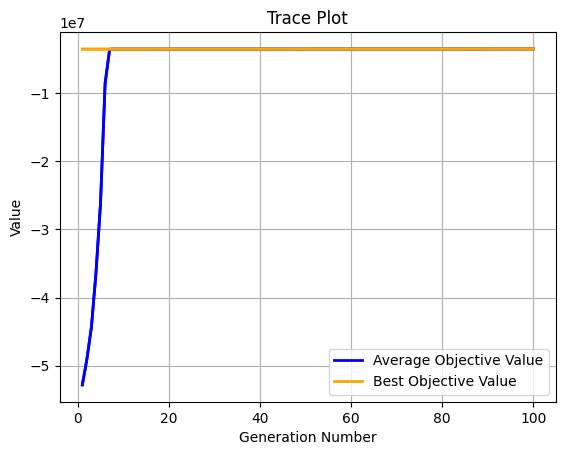

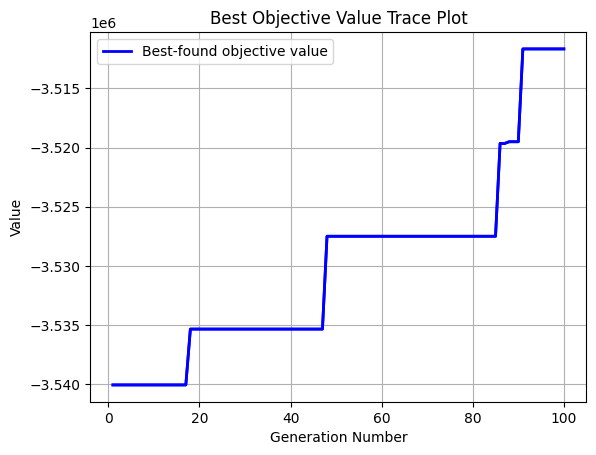

In [19]:

# 构建算法
algorithm = ea.soea_SEGA_templet(
    problem,
    ea.Population(Encoding='RI', NIND=20),
    MAXGEN=100,  # 最大进化代数。
    logTras=1,  # 表示每隔多少代记录一次日志信息，0表示不记录。
    outFunc=outFunc)  # 进化停滞计数器最大上限值。
    #algorithm.mutOper.F = 0.5  # 差分进化中的参数F
    #algorithm.recOper.XOVR = 0.7  # 重组概率
# 求解
res = ea.optimize(algorithm,
                  prophet=prohets,
                  verbose=True,
                  drawing=1,
                  outputMsg=False,
                  drawLog=True,
                  saveFlag=True)
# 对top_10列表按照目标函数值从小到大排序
top_10_sorted = np.array(sorted(top_10, key=lambda x: x[-1], reverse=True))

np.savetxt(
    f'../data/top10_2024.csv', top_10_sorted, delimiter=',')

In [20]:
ans = pd.read_csv("../data/top10_2024.csv", header=None)
print(cal_profit(prohet))

5901729.270027161


In [21]:
new=crop_data
for i in range(len(new)):
    new.loc[i,'种植规模']=ans.iloc[0,i]
    new.loc[i,'是否种']=ans.iloc[0,i+966]
lirun = cal_profit(new)
print('利润为：', lirun)
name = str(now_years)+'-'+str(lirun)
if is_delayed_sales:
    address = f"../data/问题一/打折卖出/{name}.csv"
else:
    address = f'../data/问题一/滞销/{name}.csv'
print(f'已保存至地址：{address}')
new.to_csv(address)

利润为： 5901729.270027161
已保存至地址：../data/问题一/滞销/2030-5901729.270027161.csv
